<a href="https://colab.research.google.com/github/wlrjs1300-coder/AI_26/blob/main/06_02_k%ED%8F%89%EA%B7%A0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# k-평균(K-Means)은 정답이 없는 데이터에서
# 비슷한 것끼리 자동으로 묶어주는 비지도 학습 알고리즘이다.

# 각 그룹의 대표값(평균 위치)을 계산하는데,
# 이 대표점을 "클러스터 중심" 또는 "센트로이드(centroid)"라고 부른다.

# ---------------------------------------------
# [전체 동작 과정]

# 1️⃣ 처음에는 k개의 중심점을 무작위로 선택한다.
#    (예: 바나나 하나, 사과 하나, 파인애플 하나를 대표로 찍어둠)

# 2️⃣ 모든 데이터를 하나씩 보면서
#    가장 가까운 중심점에 배정한다.
#    (각 과일을 가장 비슷한 대표 과일 쪽으로 줄 세우기)

# 3️⃣ 각 그룹에 모인 데이터들의 평균 위치를 다시 계산한다.
#    → 새로운 중심점이 만들어진다.
#    (그룹의 진짜 중심으로 대표 과일을 다시 옮기는 과정)

# 4️⃣ 중심점이 더 이상 움직이지 않을 때까지
#    2번과 3번 과정을 반복한다.
#    (자리 이동이 멈추면 학습 종료)

# ---------------------------------------------
# [예시 흐름 설명]

# 1단계 : 처음에는 중심이 엉뚱한 위치에 있을 수 있다.
# 예:
# 바나나, 바나(중심)나, 사과
# 사과, 사과,(중심), 파인애플
# 바나나, 파인(중심)애플, 파인애플

# 2단계 : 각 데이터가 가장 가까운 중심 쪽으로 재배치된다.
# 그리고 중심이 평균 위치로 이동한다.
# 예:
# 바나(중심)나, 바나나, 바나나
# 사과, 사과,(중심), 사과
# 파인애플, 파인애플, 파인(중심)애플

# 3단계 : 다시 평균을 계산해 중심을 조금 더 정확한 위치로 이동
# 예:
# 바나나, 바나(중심)나, 바나나
# 사과, 사과(중심), 사과
# 파인애플, 파인(중심)애플, 파인애플

# 이렇게 중심이 더 이상 움직이지 않으면
# 군집이 완성된다.

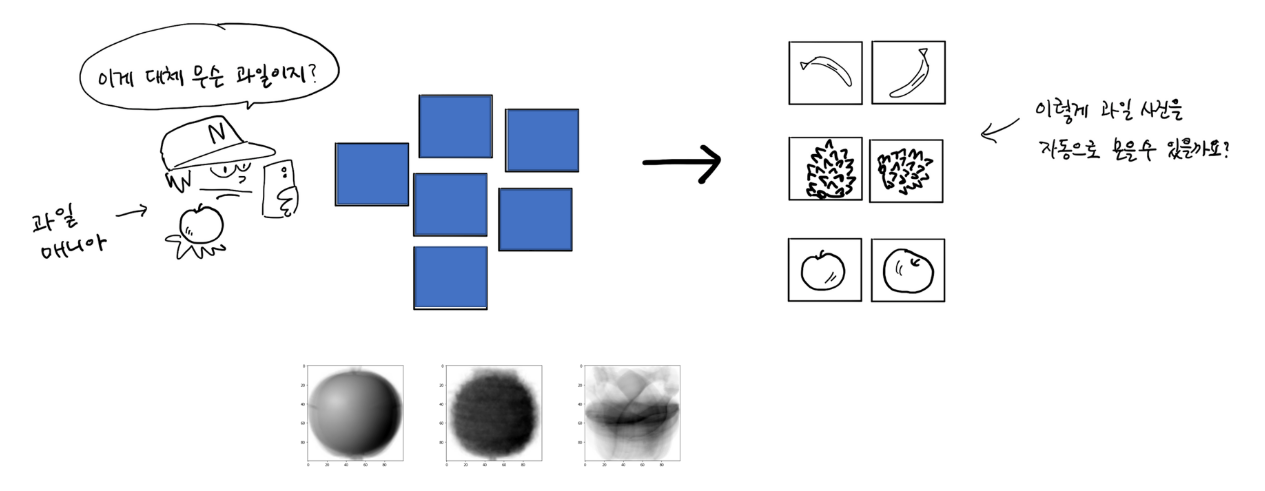

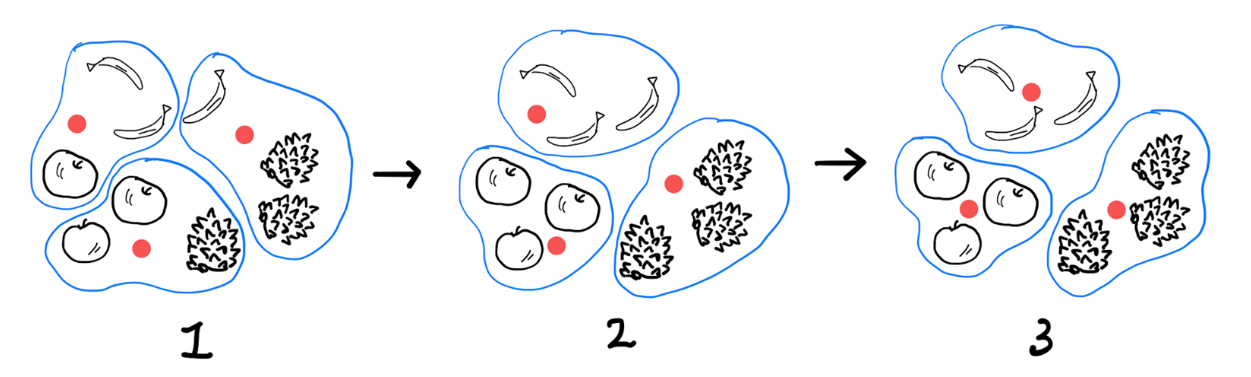

In [1]:
!wget https://bit.ly/fruits_300_data -O fruits_300.npy

--2026-03-03 07:12:53--  https://bit.ly/fruits_300_data
Resolving bit.ly (bit.ly)... 67.199.248.11, 67.199.248.10
Connecting to bit.ly (bit.ly)|67.199.248.11|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/rickiepark/hg-mldl/raw/master/fruits_300.npy [following]
--2026-03-03 07:12:53--  https://github.com/rickiepark/hg-mldl/raw/master/fruits_300.npy
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fruits_300.npy [following]
--2026-03-03 07:12:54--  https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fruits_300.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... conne

In [2]:
import numpy as np

# 과일 이미지 데이터 불러오기
# fruits_300.npy 파일에는 300장의 이미지가 들어 있음
# 각 이미지는 100 x 100 크기
# 즉, 전체 모양은 (300, 100, 100)
fruits = np.load('fruits_300.npy')

# 이미지는 3차원 구조
# (이미지개수, 높이, 너비)
# 그런데 머신러닝 모델은 보통 2차원 데이터를 사용함
# 그래서 (이미지개수, 픽셀총개수) 형태로 변환

# -1은 "이미지 개수는 자동 계산해줘" 라는 의미
# 100*100은 한 장의 이미지 픽셀 개수 (10000개)
# 결과 모양은 (300, 10000)
fruits_2d = fruits.reshape(-1, 100*100)

# 원래 데이터 모양 확인
# (300, 100, 100) 형태로 출력됨
print(fruits.shape)

(300, 100, 100)


In [3]:
print(fruits_2d.shape)

(300, 10000)


In [4]:
from sklearn.cluster import KMeans
# sklearn(사이킷런) 라이브러리의 cluster 모듈 안에 있는
# KMeans 알고리즘 클래스를 가져온다.

# KMeans 객체 생성
# n_clusters=3  →  데이터를 3개의 그룹으로 나누겠다는 의미
# random_state=42 → 처음 중심점을 랜덤으로 정하는데,
#                   항상 같은 결과가 나오도록 난수 고정
km = KMeans(n_clusters=3, random_state=42)

# 비지도 학습이므로 정답(target)을 주지 않는다.
# 단순히 데이터(fruits_2d)만 넣어서
# 비슷한 것끼리 자동으로 묶도록 학습시킨다.
km.fit(fruits_2d)

KMeans(n_clusters=3, random_state=42)

In [5]:
print(km.labels_)

[2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 0 2 0 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 0 0 2 2 2 2 2 2 2 2 0 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1]


In [7]:
# 현재 클러스터 번호(0, 1, 2)가
# 실제로 어떤 과일을 의미하는지는 아직 모른다.
# (0이 바나나일 수도 있고, 사과일 수도 있음)
# 그래서 직접 이미지를 확인해야 한다.

# np.unique()는 배열 안의 "서로 다른 값"을 찾아준다.
# return_counts=True 옵션을 주면
# 각 값이 몇 개씩 있는지도 함께 반환한다.

print(np.unique(km.labels_, return_counts=True))

# 예시 출력:
# (array([0, 1, 2]), array([112, 98, 90]))

# 의미:
# 0번 클러스터에 112개
# 1번 클러스터에 98개
# 2번 클러스터에 90개 데이터가 배정되었다는 뜻

(array([0, 1, 2], dtype=int32), array([112,  98,  90]))


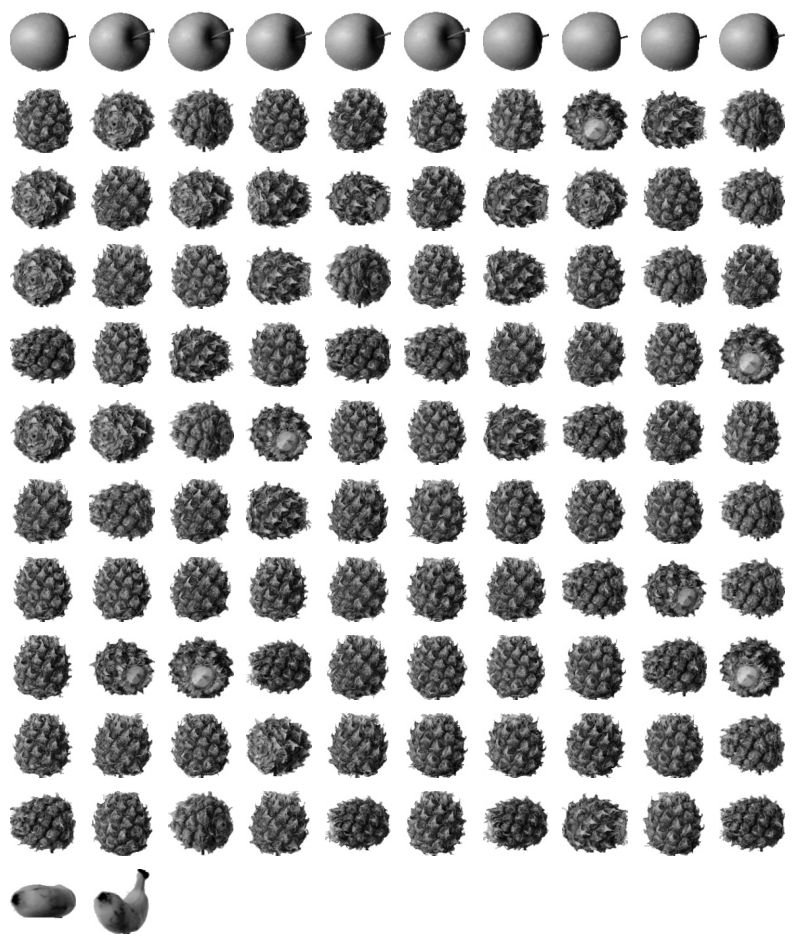

In [8]:
# 여러 개의 이미지를 한 번에 출력하기 위한 함수 정의
import matplotlib.pyplot as plt

def draw_fruits(arr, ratio=1):
    # arr : 출력할 이미지 배열 (예: 특정 클러스터에 속한 이미지들)
    # ratio : 그림 크기 비율 조정값

    n = len(arr)
    # n은 출력할 이미지 개수

    # 한 줄에 최대 10개씩 이미지를 배치
    # 전체 행 개수 = 이미지 개수 / 10 (올림 처리)
    rows = int(np.ceil(n / 10))

    # 행이 1개면 열은 이미지 개수만큼
    # 행이 2개 이상이면 열은 10개로 고정
    cols = n if rows < 2 else 10

    # subplot 생성
    # figsize는 전체 그림 크기 (열 개수 × 행 개수에 비례)
    # squeeze=False는 항상 2차원 배열 형태로 axs를 유지
    fig, axs = plt.subplots(rows, cols,
                            figsize=(cols * ratio, rows * ratio),
                            squeeze=False)

    # 각 위치에 이미지 하나씩 출력
    for i in range(rows):
        for j in range(cols):
            # 전체 이미지 개수 n을 넘지 않는 경우만 그림
            if i * 10 + j < n:
                axs[i, j].imshow(arr[i * 10 + j], cmap='gray_r')

            # 축 눈금 제거 (이미지에 집중하기 위해)
            axs[i, j].axis('off')

    plt.show()


# km.labels_ == 0 인 데이터만 선택
# 즉, 0번 클러스터에 속한 이미지들만 추출
draw_fruits(fruits[km.labels_ == 0])

# 결과:
# 0번 그룹에 속한 112개의 이미지가 화면에 출력됨
# 이 이미지를 보고 0번 클러스터가 어떤 과일인지 직접 판단할 수 있음